# Blackbox Optimisation Project: Week Three


This extends the boundary box approach from week 2. Rather than manually specifying a a bounding box from inspection of the input-output scatter, this code classifies the data with a binary "promising" channel.  <br><br> -- Data points with an output in the upper quartile of values are given a "promising" value of 1, others are 0 <br> -- A convex hull is then drawn around the subset of points defined as being "promising" <br> -- This convex hull i sthen searched for the most-isolated point as in week 1, but the search region is now concentrated around points that appear to be close to the maximum

In [319]:
week = 4

Import Standard Libraries

In [320]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path

import matplotlib.pyplot as plt

Import Project Packages

In [321]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

#### Import data and create output directories

In [ ]:
function = 2

In [323]:
# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)
print(f"Requested function {function} in week {week}")

Requested function 2 in week 4


In [324]:
# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"results will be saved to {results_dir}")

results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_4\function_2


In [325]:
# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)


Loaded initial data: function_2


In [326]:
# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)


Available update files:
1: new_data_point_wk1.csv
2: new_data_point_wk2.csv
3: new_data_point_wk3.csv
Added 3 new data points.


#### Augment data set

In [327]:
# separate inputs from outputs
input_cols = data_loading.get_X_cols(df)

In [328]:
# Scale the outputs
df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])

Classify promising regions

In [329]:
quantile = 0.75
threshold = df["YScaled"].quantile(quantile)

while (df["YScaled"] >= threshold).astype(int).sum() < len(input_cols) + 1:
    quantile = quantile - 0.05
    threshold = df["YScaled"].quantile(quantile)

    print(quantile)

df["promising"] = (df["YScaled"] >= threshold).astype(int)

In [330]:
df_inputs = df[input_cols]
df_output = df["YScaled"]

Find most isolated point in the input space, bound by the convex hull of all inputs data

In [331]:
df_hull = df[df["promising"] == 1]
df_hull_inputs = df_hull[input_cols]

In [332]:
hull, points_hull = data_augmentation.compute_convex_hull(df_hull_inputs)

In [333]:
best_point, best_dist = data_augmentation.most_isolated_point(points_hull, hull, n_samples=10000, seed=42)

def to_dict(point, columns):
    return {col: val for col, val in zip(columns, point)}

best_point_dict = to_dict(best_point, input_cols)

#### Plot Results

In [334]:
points = df_inputs.to_numpy()
new_point_flag = df["new data point"].to_numpy()

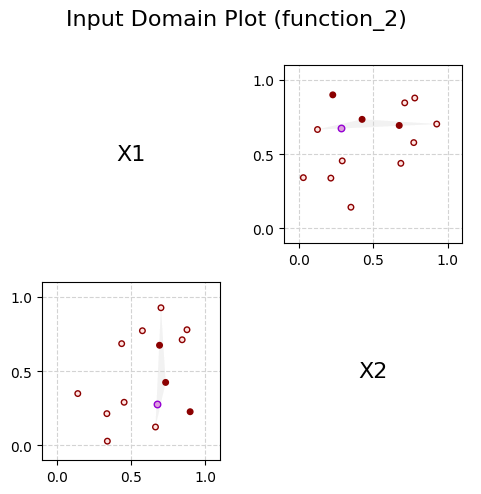

In [335]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_hull, new_point_flag, hull = hull,next_point = best_point_dict)

In [336]:
X = df_inputs.to_numpy()
Y = df_output.to_numpy()

Y = np.asarray(Y).reshape(-1, 1)
Z = df["promising"].to_numpy().reshape(-1, 1) 

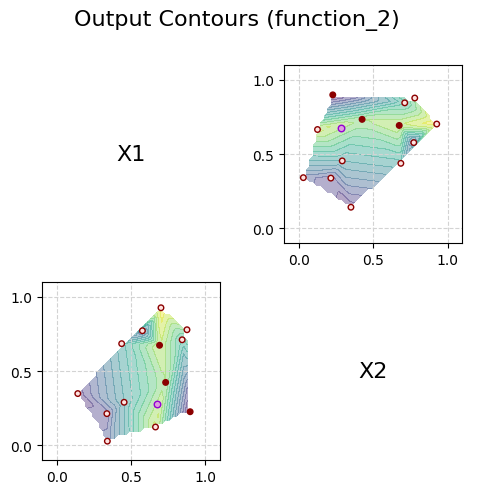

In [337]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_hull, new_point_flag, contour = Y[:, 0],next_point = best_point_dict)

(<Figure size 500x250 with 2 Axes>,
 array([[<Axes: xlabel='X1', ylabel='Y1'>, <Axes: xlabel='X2'>]],
       dtype=object))

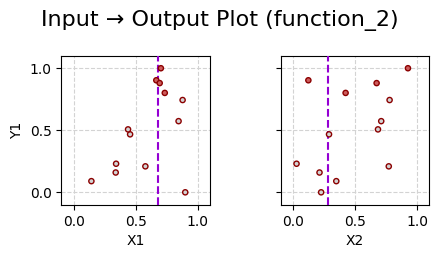

In [338]:
data_plotting.domain_io_plot(data_folder_name,results_dir,input_cols,["Y1"],X,Y,Z,next_point=best_point_dict)

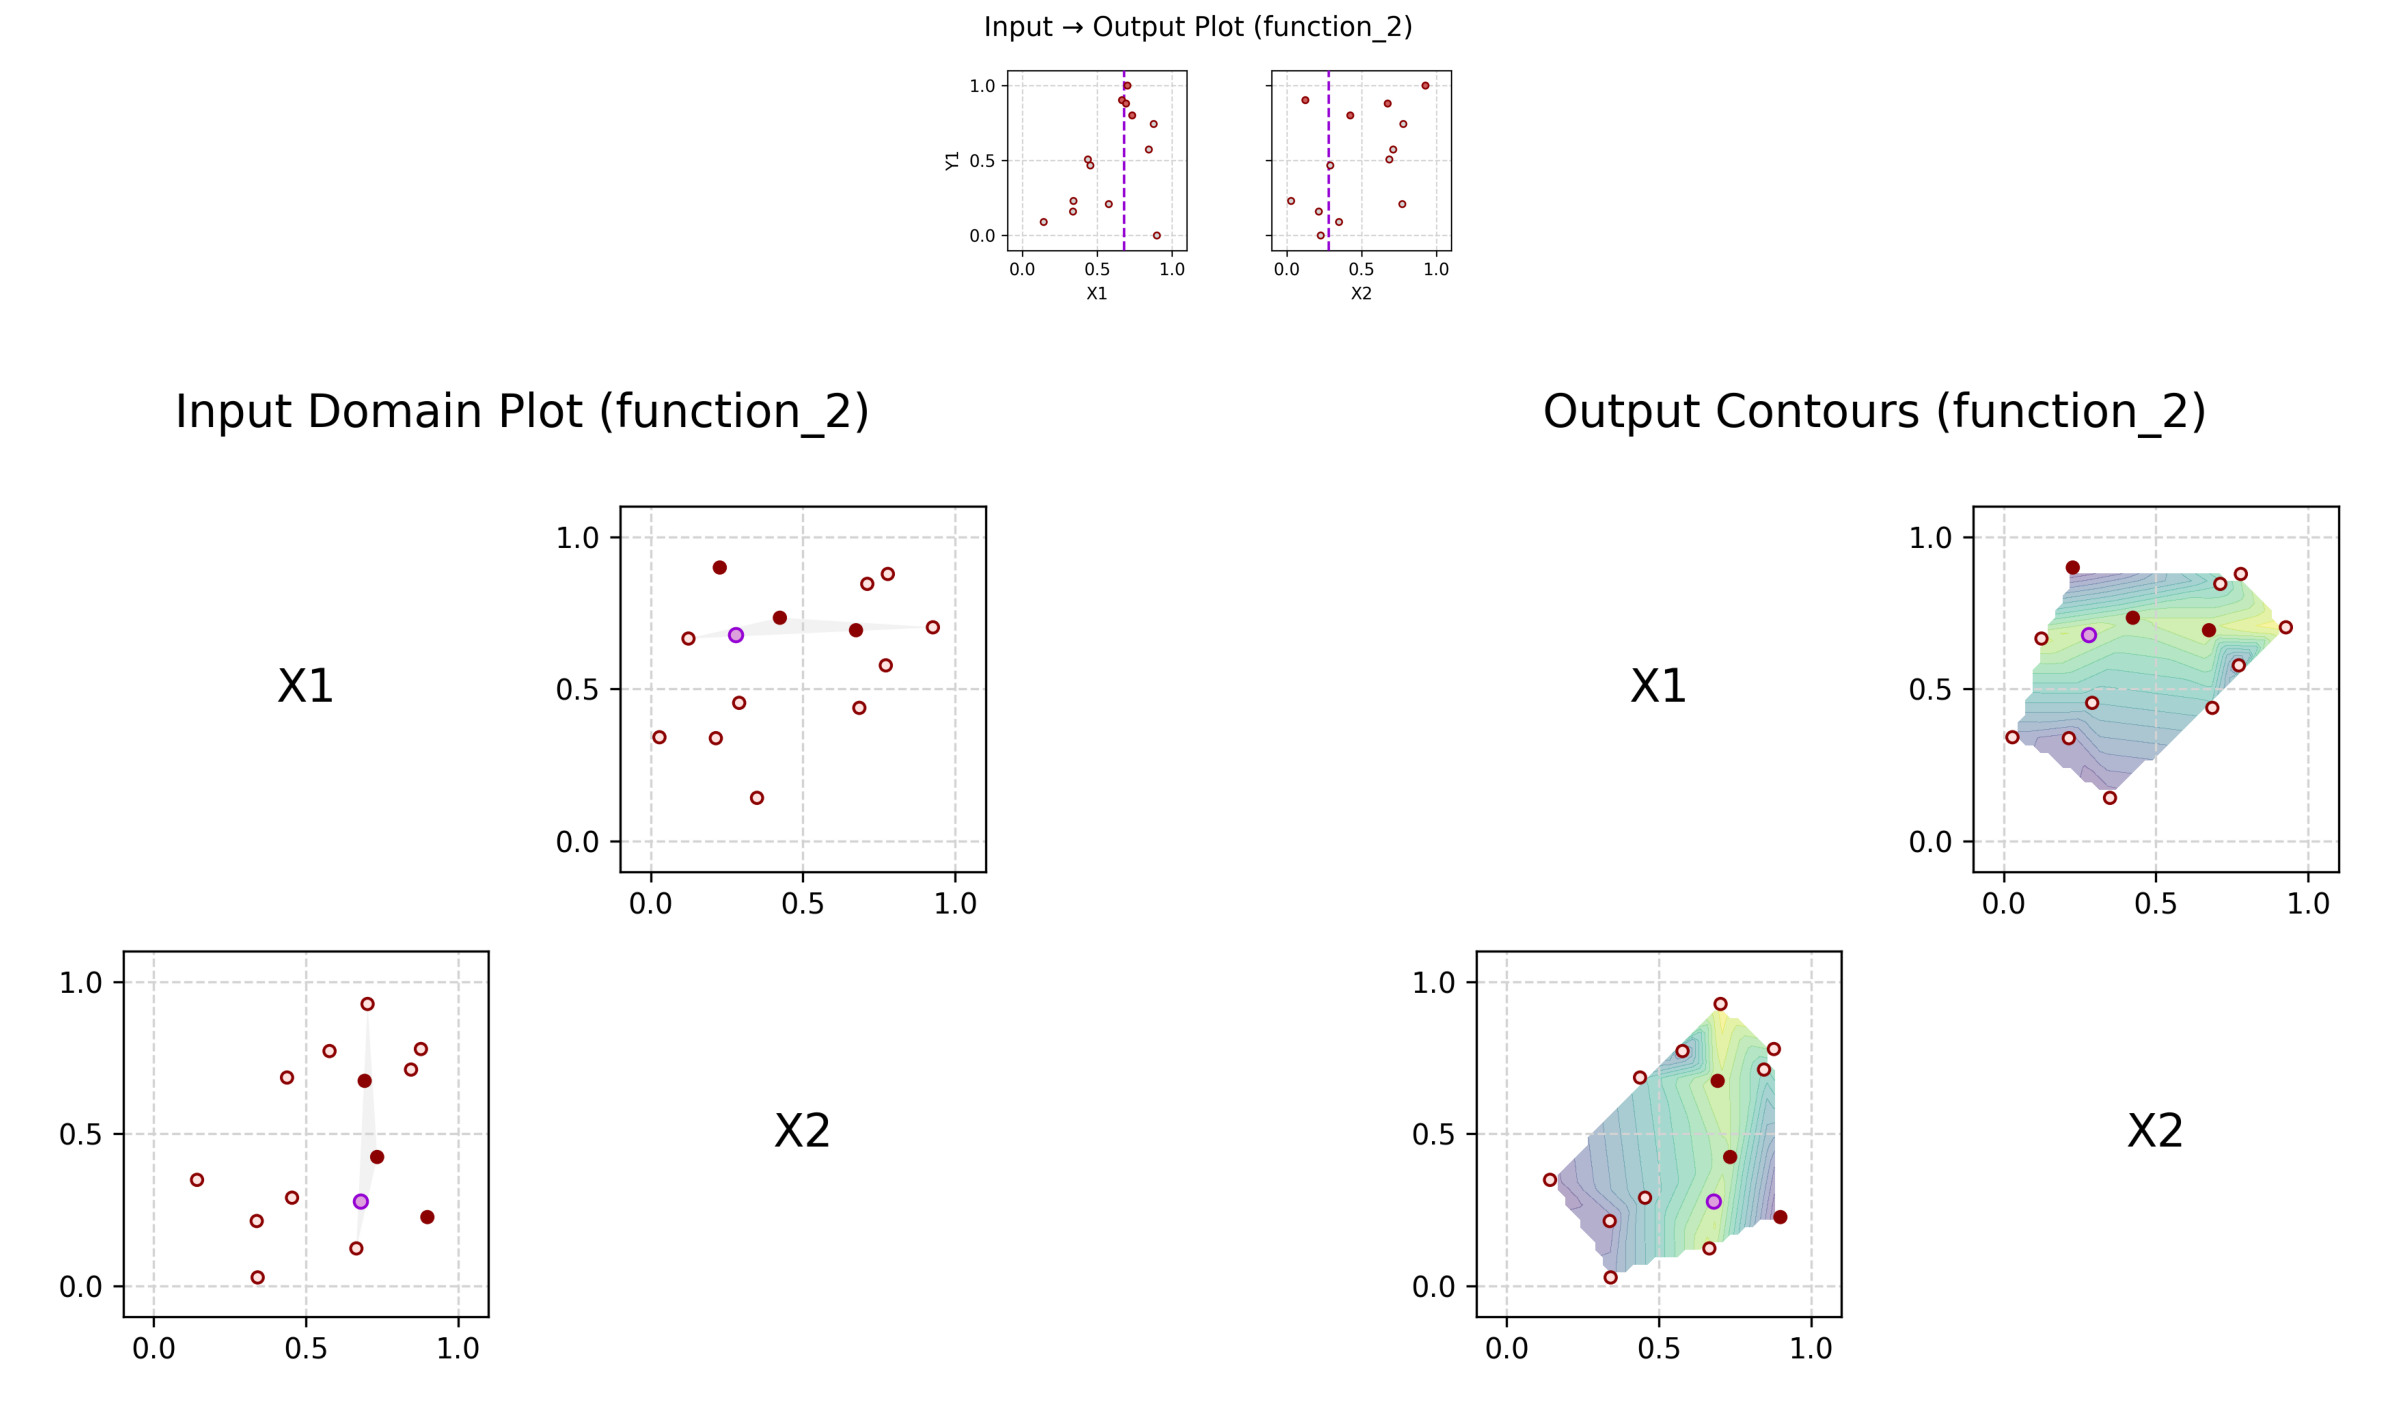

In [339]:
import matplotlib.image as mpimg

# Create a figure and a grid layout
fig = plt.figure(figsize=(32, 18))
gs = fig.add_gridspec(4,2)

# # Map
search_region_path = results_dir / ("domain_scatter.png")
output_contour_path = results_dir / ("domain_scatter_contour.png")
io_path = results_dir / ("io_scatter.png")

search_region = mpimg.imread(search_region_path)
output_contour = mpimg.imread(output_contour_path)
io = mpimg.imread(io_path)

ax1 = fig.add_subplot(gs[1:,0])
ax1.imshow(search_region)
ax1.axis('off')

ax2 = fig.add_subplot(gs[1:,1])
ax2.imshow(output_contour)
ax2.axis('off')

ax3 = fig.add_subplot(gs[0,:])
ax3.imshow(io)
ax3.axis('off')

save_filename = results_dir / "collated_results.png"
plt.savefig(save_filename, dpi=300)

#### write next point to csv

In [340]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [341]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.678805-0.278876
